# Renal Complications in DiabetIA dataset

## 1. Data preparation

This phase covers the complete preprocessing pipeline applied to the
DiabetIA dataset prior to any modelling. It includes missing value
analysis, variable filtering, imputation, encoding, and normalization.
All steps are applied to the full dataset (42,181 records) before
the train/test split to avoid any data leakage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

dataset = pd.read_csv("hk_database.csv")

print(f"Dataset loaded: {dataset.shape[0]} records · {dataset.shape[1]} variables")
print(f"\nClass distribution (e112):\n{dataset['e112'].value_counts()}")

Dataset loaded: 477036 records · 520 variables

Class distribution (e112):
e112
0.0    464929
1.0     12107
Name: count, dtype: int64


## 2. Compute `age` field

In [5]:
from datetime import datetime

dataset['birthdate'] = pd.to_datetime(dataset['birthdate'])

fecha_referencia = datetime(2023, 10, 23)

dataset['edad'] = dataset['birthdate'].apply(
    lambda x: fecha_referencia.year - x.year - (
        (fecha_referencia.month, fecha_referencia.day) < (x.month, x.day)
    )
)
print("✔️")

✔️


## 3. Variable selection and missing values

From the original 23 variables, we apply a missing value analysis using the `missingno` library to identify variables with high proportions of missing data.

Variables selected: 24


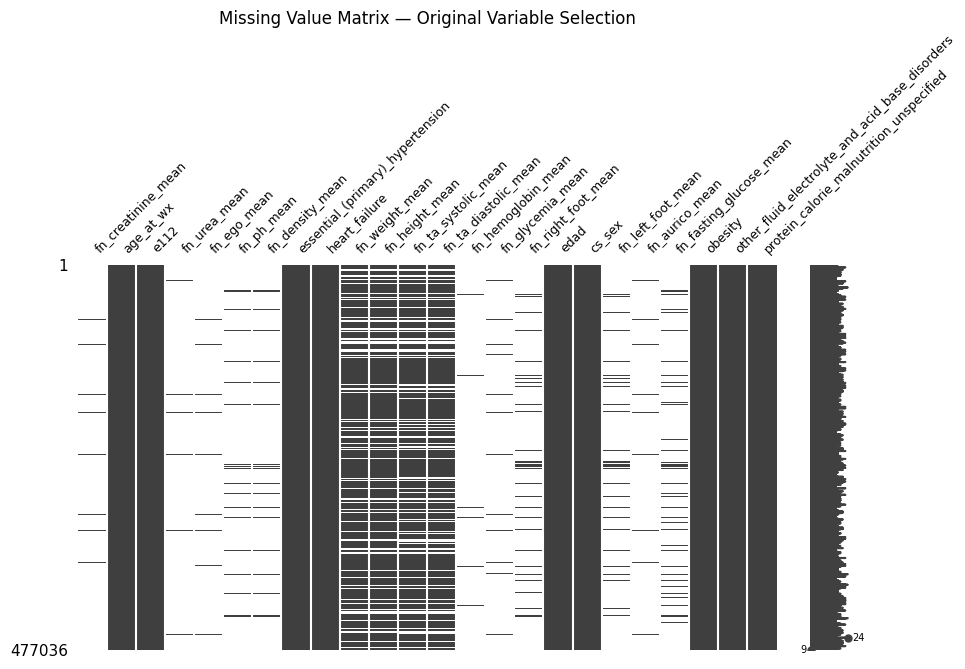


Missing value proportion per variable:
 fn_urea_mean                                       0.983
fn_hemoglobin_mean                                 0.982
fn_ego_mean                                        0.974
fn_creatinine_mean                                 0.966
fn_aurico_mean                                     0.966
fn_density_mean                                    0.959
fn_ph_mean                                         0.959
fn_glycemia_mean                                   0.952
fn_right_foot_mean                                 0.938
fn_left_foot_mean                                  0.938
fn_fasting_glucose_mean                            0.903
fn_ta_systolic_mean                                0.184
fn_ta_diastolic_mean                               0.184
fn_weight_mean                                     0.157
fn_height_mean                                     0.157
age_at_wx                                          0.000
essential_(primary)_hypertension               

In [6]:
variables_seleccionadas = [
    'fn_creatinine_mean',
    'age_at_wx',
    'e112',
    'fn_urea_mean',
    'fn_ego_mean',
    'fn_ph_mean',
    'fn_density_mean',
    'essential_(primary)_hypertension',
    'heart_failure',
    'fn_weight_mean',
    'fn_height_mean',
    'fn_ta_systolic_mean',
    'fn_ta_diastolic_mean',
    'fn_hemoglobin_mean',
    'fn_glycemia_mean',
    'fn_right_foot_mean',
    'edad',
    'cs_sex',
    'fn_left_foot_mean',
    'fn_aurico_mean',
    'fn_fasting_glucose_mean',
    'obesity',
    'other_fluid_electrolyte_and_acid_base_disorders',
    'drugs_used_in_nephrology',
    'protein_calorie_malnutrition_unspecified',
]

variables_existentes = [v for v in variables_seleccionadas if v in dataset.columns]
df_subconjunto = dataset[variables_existentes].copy()

print(f"Variables selected: {len(variables_existentes)}")

# Missing value matrix
msno.matrix(df_subconjunto, figsize=(10, 5), fontsize=9)
plt.title("Missing Value Matrix — Original Variable Selection", fontsize=12)
plt.tight_layout()
plt.savefig('fig_missing_before.pdf', bbox_inches='tight')
plt.show()

# Missing value proportions
nulls = df_subconjunto.isnull().mean().sort_values(ascending=False)
print("\nMissing value proportion per variable:\n", nulls.round(3))

## 4. Exclusion criterion

Variables with more than 40% missing values are excluded from
the analysis. This criterion resulted in the removal of 10 variables,
reducing the feature space from 23 to 13 variables.

In [7]:
threshold = 0.40
excluded = nulls[nulls > threshold]
kept     = nulls[nulls <= threshold]

print(f"Variables excluded (>{threshold*100:.0f}% missing): {len(excluded)}")
print(excluded)
print(f"\nVariables retained: {len(kept)}")

df_filtrado = df_subconjunto[kept.index].copy()
print(f"\nFiltered dataset: {df_filtrado.shape[0]} records · {df_filtrado.shape[1]} variables")

Variables excluded (>40% missing): 11
fn_urea_mean               0.983186
fn_hemoglobin_mean         0.981609
fn_ego_mean                0.973635
fn_creatinine_mean         0.965596
fn_aurico_mean             0.965567
fn_density_mean            0.959242
fn_ph_mean                 0.959192
fn_glycemia_mean           0.952274
fn_right_foot_mean         0.937875
fn_left_foot_mean          0.937655
fn_fasting_glucose_mean    0.902726
dtype: float64

Variables retained: 13

Filtered dataset: 477036 records · 13 variables


## 6. Data preprocessing

1. **Imputation** — median for numerical variables, mode for categorical
2. **Encoding** — categorical variables encoded as numerical
3. **Normalization** — continuous features scaled to [0, 1]

In [8]:
# Imputation
from sklearn.impute import SimpleImputer

num_vars = df_filtrado.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_vars = df_filtrado.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

# Remove target from imputation
if 'e112' in num_vars:
    num_vars.remove('e112')

# Numerical: median imputation
imp_num = SimpleImputer(strategy='median')
df_filtrado[num_vars] = imp_num.fit_transform(df_filtrado[num_vars])

# Categorical: mode imputation
if len(cat_vars) > 0:
    imp_cat = SimpleImputer(strategy='most_frequent')
    df_filtrado[cat_vars] = imp_cat.fit_transform(df_filtrado[cat_vars])

print("Imputation complete.")
print(f"Missing values remaining: {df_filtrado.isnull().sum().sum()}")

Imputation complete.
Missing values remaining: 0


In [9]:
# Encoding
df_encoded = pd.get_dummies(df_filtrado, columns=cat_vars, drop_first=True)

print(f"After encoding: {df_encoded.shape[0]} records · {df_encoded.shape[1]} variables")

After encoding: 477036 records · 13 variables


In [13]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

target = 'e112'
features_to_scale = [c for c in df_encoded.columns
                     if c != target and df_encoded[c].dtype in ['float64', 'float32']]

scaler = MinMaxScaler()
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print(f"Normalization complete. Features scaled: {len(features_to_scale)}")

Normalization complete. Features scaled: 11


NaN en e112: 0
Inf en e112: 0
————————————————————————————————————————————————————————————
PROCESSED DATASET — READY FOR MODELLING
————————————————————————————————————————————————————————————
Records   : 477,036
Variables : 13
Missing   : 0
Prevalence: 2.54%

Class distribution:
e112
0    464929
1     12107
Name: count, dtype: int64


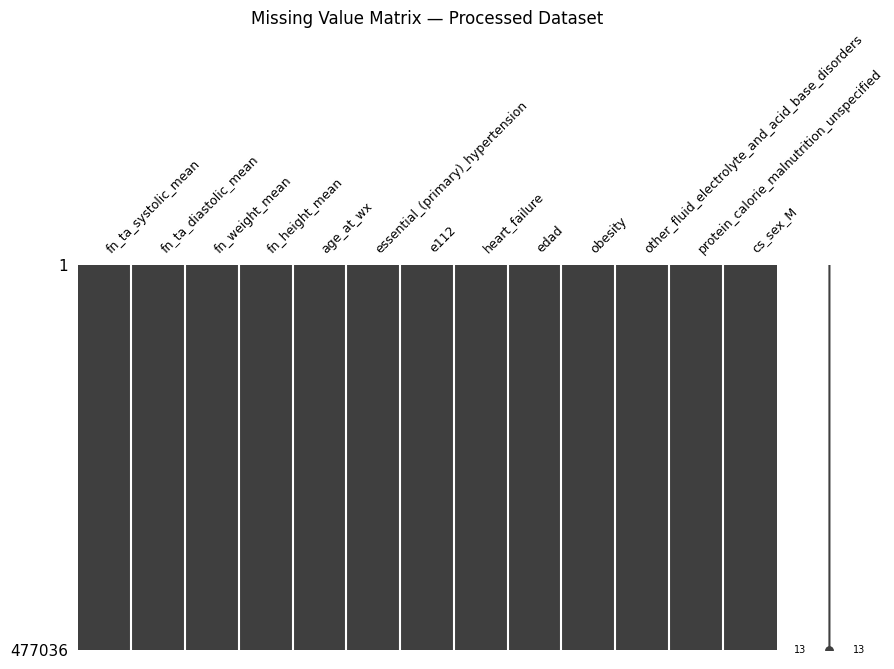

In [15]:
df_procesado = df_encoded.copy()
# Verificar NaN en target antes de convertir
print(f"NaN en e112: {df_procesado['e112'].isnull().sum()}")
print(f"Inf en e112: {np.isinf(df_procesado['e112']).sum()}")

# Eliminar filas con NaN en el target y convertir
df_procesado = df_procesado.dropna(subset=['e112'])
df_procesado['e112'] = df_procesado['e112'].astype(int)

print("—" * 60)
print("PROCESSED DATASET — READY FOR MODELLING")
print("—" * 60)
print(f"Records   : {df_procesado.shape[0]:,}")
print(f"Variables : {df_procesado.shape[1]}")
print(f"Missing   : {df_procesado.isnull().sum().sum()}")
print(f"Prevalence: {df_procesado['e112'].mean()*100:.2f}%")
print(f"\nClass distribution:\n{df_procesado['e112'].value_counts()}")

# Missing value matrix after preprocessing
msno.matrix(df_procesado, figsize=(10, 5), fontsize=9)
plt.title("Missing Value Matrix — Processed Dataset", fontsize=12)
plt.tight_layout()
plt.savefig('fig_missing_after.pdf', bbox_inches='tight')
plt.show()

---

# Imbalanced classification pipeline
**Target:** `e112` | **Imbalance ratio:** ~37:1 | **Seed:** 42

Pipeline:
1. 80/20 stratified split.
2. SMOTE on train only.
3. 5-fold CV on train with 5% confidence interval.
4. GradientBoosting, LightGBM, RandomForest, XGBoost, ExplainableBoostingMachine
5. Validation on untouched imbalanced test set.

## 0. Dependencies

In [1]:
!pip install interpret --quiet
!pip install lightgbm --quiet
!pip install xgboost --quiet

from importlib.metadata import version

print("interpret vers:", version('interpret'))
print("lightgbm:", version('lightgbm'))
print("xgboost:", version('xgboost'))
print("Install packages ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 44.5 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 76.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 85.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 91.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 16.5 MB/s eta 0:00:00
interpret vers: 0.7.8
lightgbm: 4.6.0
xgboost: 3.2.0
Install packages ✅


## 1. Imports & configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from tqdm.auto import tqdm

# Splitting & preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder

# SMOTE
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Classifiers
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print("Imports ✅ SEED =", SEED)

Imports ✅ — SEED = 42


## 2. Load data & 80/20 stratified split

In [ ]:
TARGET = "e112"
df = pd.read_csv("unbalanced_dataset.csv")

# Encode boolean column
df["cs_sex_M"] = df["cs_sex_M"].astype(int)

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print(f"Dataset shape : {df.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Imbalance ratio : {y.value_counts()[0] / y.value_counts()[1]:.1f}:1")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f"\nTrain size : {X_train.shape[0]}  |  Test size : {X_test.shape[0]}")
print(f"Train positives : {y_train.sum()} ({100*y_train.mean():.2f}%)")
print(f"Test  positives : {y_test.sum()}  ({100*y_test.mean():.2f}%)")

Dataset shape : (42181, 13)
Class distribution:
e112
0    41089
1     1092
Name: count, dtype: int64
Imbalance ratio : 37.6:1

Train size : 33744  |  Test size : 8437
Train positives : 874 (2.59%)
Test  positives : 218  (2.58%)


## 3. SMOTE on training set only

In [4]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(f"  Train shape  : {X_train_sm.shape}")
print(f"  Class counts : {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"\nTest set is untouched. Shape: {X_test.shape}")

After SMOTE:
  Train shape  : (65740, 12)
  Class counts : {0: 32870, 1: 32870}

Test set is UNTOUCHED — shape: (8437, 12)


## 4. 5-fold CV + Confidence Interval (95%)

In [5]:
CV_FOLDS      = 5
ALPHA         = 0.05 # 5% significance → 95% CI
CV_SCORING    = [
    "balanced_accuracy",
    "f1",
    "roc_auc",
    "average_precision",
]

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def run_cv(model, X, y, model_name="Model"):
    """Run 5-fold CV and return a dataFrame with 95% CIs."""
    print(f"\n{'='*60}")
    print(f"  5-Fold CV — {model_name}")
    print(f"{'='*60}")

    cv_results = cross_validate(
        model, X, y,
        cv=skf,
        scoring=CV_SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

    rows = []
    for metric in CV_SCORING:
        key    = f"test_{metric}"
        scores = cv_results[key]
        mean   = scores.mean()
        se     = stats.sem(scores)
        ci     = se * stats.t.ppf(1 - ALPHA / 2, df=CV_FOLDS - 1)
        rows.append({
            "Metric"      : metric.replace("_", " ").title(),
            "Mean"        : round(mean, 4),
            "Std"         : round(scores.std(), 4),
            "95% CI lower": round(mean - ci, 4),
            "95% CI upper": round(mean + ci, 4),
            "Fold scores" : np.round(scores, 4).tolist(),
        })

    df_cv = pd.DataFrame(rows).set_index("Metric")
    print(df_cv[["Mean", "Std", "95% CI lower", "95% CI upper"]].to_string())
    return df_cv


def evaluate_test(model, X_tr, y_tr, X_te, y_te, model_name="Model"):
    """Fit on full train, evaluate on imbalanced test set."""
    print(f"\n{'='*60}")
    print(f"  Test Evaluation — {model_name}")
    print(f"{'='*60}")

    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Balanced accuracy": balanced_accuracy_score(y_te, y_pred),
        "F1 Score"         : f1_score(y_te, y_pred, zero_division=0),
        "Brier score"      : brier_score_loss(y_te, y_proba),
        "AUC (ROC-AUC)"    : roc_auc_score(y_te, y_proba),
        "PR-AUC"           : average_precision_score(y_te, y_proba),
    }

    for k, v in metrics.items():
        print(f"  {k:<22}: {v:.4f}")

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{model_name} — Test Set", fontsize=13, fontweight="bold")

    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion matrix")

    RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[1], name=model_name)
    axes[1].set_title(f"ROC Curve  (AUC={metrics['AUC (ROC-AUC)']:.3f})")

    PrecisionRecallDisplay.from_predictions(y_te, y_proba, ax=axes[2], name=model_name)
    axes[2].set_title(f"PR Curve  (AP={metrics['PR-AUC']:.3f})")

    plt.tight_layout()
    plt.show()

    return metrics

# Store all test results for final comparison
all_test_results = {}
print("Functions ✅")

Helper functions defined.


## 5. GradientBoostingClassifier

Running GradientBoosting CV (this may take a few minutes) …


GB CV folds:   0%|          | 0/5 [00:00<?, ?it/s]


  5-Fold CV — GradientBoostingClassifier
                     Mean     Std  95% CI lower  95% CI upper
Metric                                                       
Balanced Accuracy  0.8705  0.0057        0.8626        0.8783
F1                 0.8791  0.0050        0.8722        0.8861
Roc Auc            0.9576  0.0019        0.9550        0.9602
Average Precision  0.9594  0.0016        0.9572        0.9617

Fitting GradientBoosting on full train & evaluating test …

  Test Evaluation — GradientBoostingClassifier
  Balanced Accuracy     : 0.7303
  F1 Score              : 0.1436
  Brier Score           : 0.1082
  AUC (ROC-AUC)         : 0.8381
  PR-AUC                : 0.1047


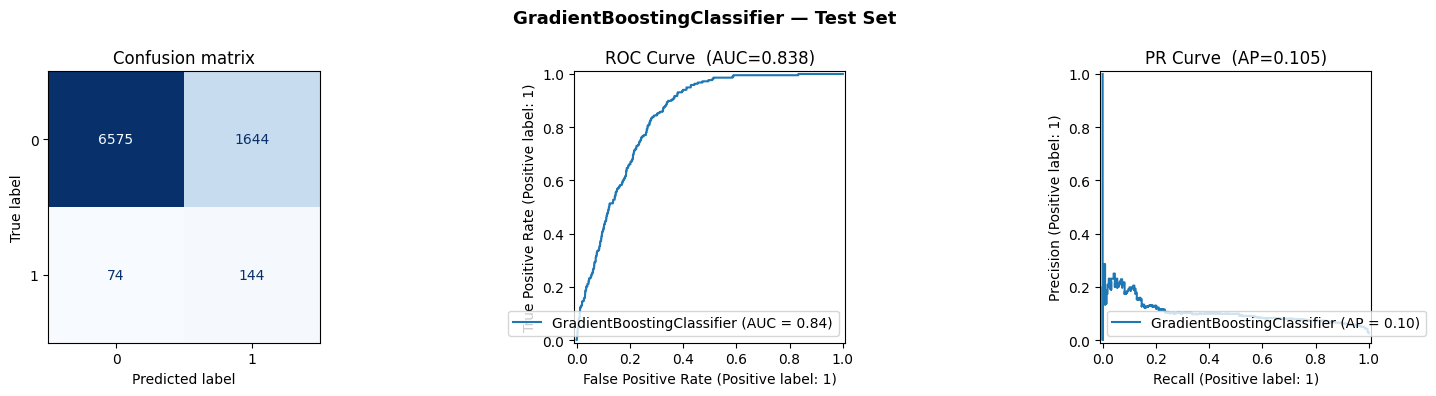

CPU times: user 20.1 s, sys: 176 ms, total: 20.2 s
Wall time: 59.4 s


In [6]:
%%time

gb_model = GradientBoostingClassifier(random_state = SEED)

print("Running GradientBoosting CV...")
with tqdm(total=CV_FOLDS, desc="GB CV folds") as pbar:
    gb_cv = run_cv(gb_model, X_train_sm, y_train_sm, "GradientBoostingClassifier")
    pbar.update(CV_FOLDS)

print("\nFitting GradientBoosting on full train & evaluating test...")
all_test_results["GradientBoosting"] = evaluate_test(
    gb_model, X_train_sm, y_train_sm, X_test, y_test, "GradientBoostingClassifier"
)

## 6. LGBMClassifier

Running LightGBM CV …


LGBM CV folds:   0%|          | 0/5 [00:00<?, ?it/s]


  5-Fold CV — LGBMClassifier
                     Mean     Std  95% CI lower  95% CI upper
Metric                                                       
Balanced Accuracy  0.9780  0.0009        0.9767        0.9793
F1                 0.9781  0.0009        0.9768        0.9793
Roc Auc            0.9974  0.0003        0.9970        0.9977
Average Precision  0.9977  0.0002        0.9974        0.9980

Fitting LightGBM on full train & evaluating test …

  Test Evaluation — LGBMClassifier
  Balanced Accuracy     : 0.6200
  F1 Score              : 0.2528
  Brier Score           : 0.0360
  AUC (ROC-AUC)         : 0.8858
  PR-AUC                : 0.2020


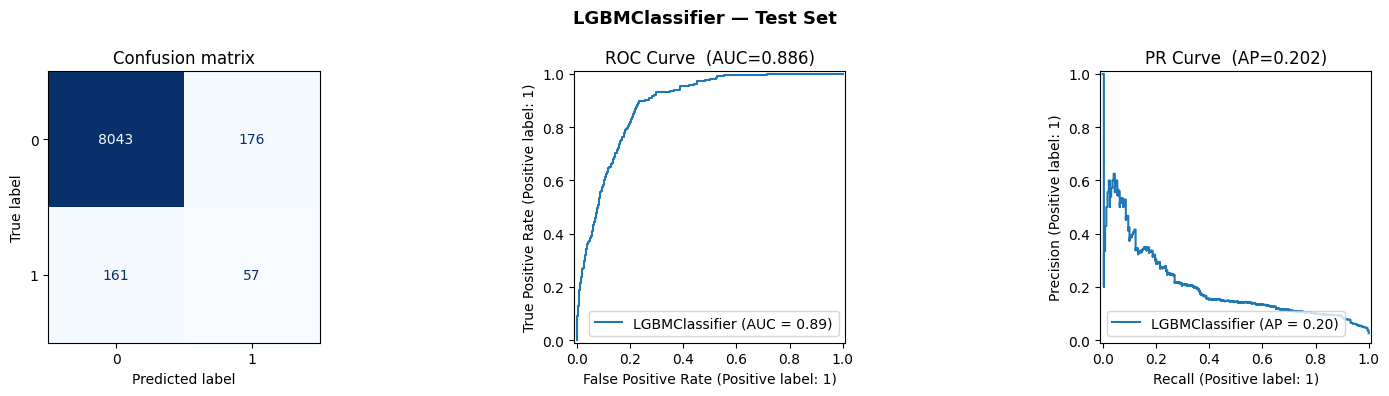

CPU times: user 1.74 s, sys: 144 ms, total: 1.88 s
Wall time: 7.36 s


In [7]:
%%time

lgbm_model = LGBMClassifier(verbose=-1, random_state = SEED)

print("Running LightGBM CV...")
with tqdm(total=CV_FOLDS, desc="LGBM CV folds") as pbar:
    lgbm_cv = run_cv(lgbm_model, X_train_sm, y_train_sm, "LGBMClassifier")
    pbar.update(CV_FOLDS)

print("\nFitting LightGBM on full train & evaluating test...")
all_test_results["LightGBM"] = evaluate_test(
    lgbm_model, X_train_sm, y_train_sm, X_test, y_test, "LGBMClassifier"
)

## 7. RandomForestClassifier

Running RandomForest CV …


RF CV folds:   0%|          | 0/5 [00:00<?, ?it/s]


  5-Fold CV — RandomForestClassifier
                     Mean     Std  95% CI lower  95% CI upper
Metric                                                       
Balanced Accuracy  0.9907  0.0006        0.9898        0.9916
F1                 0.9907  0.0006        0.9898        0.9916
Roc Auc            0.9993  0.0002        0.9991        0.9995
Average Precision  0.9994  0.0001        0.9992        0.9996

Fitting RandomForest on full train & evaluating test …

  Test Evaluation — RandomForestClassifier
  Balanced Accuracy     : 0.6478
  F1 Score              : 0.3860
  Brier Score           : 0.0233
  AUC (ROC-AUC)         : 0.9217
  PR-AUC                : 0.3947


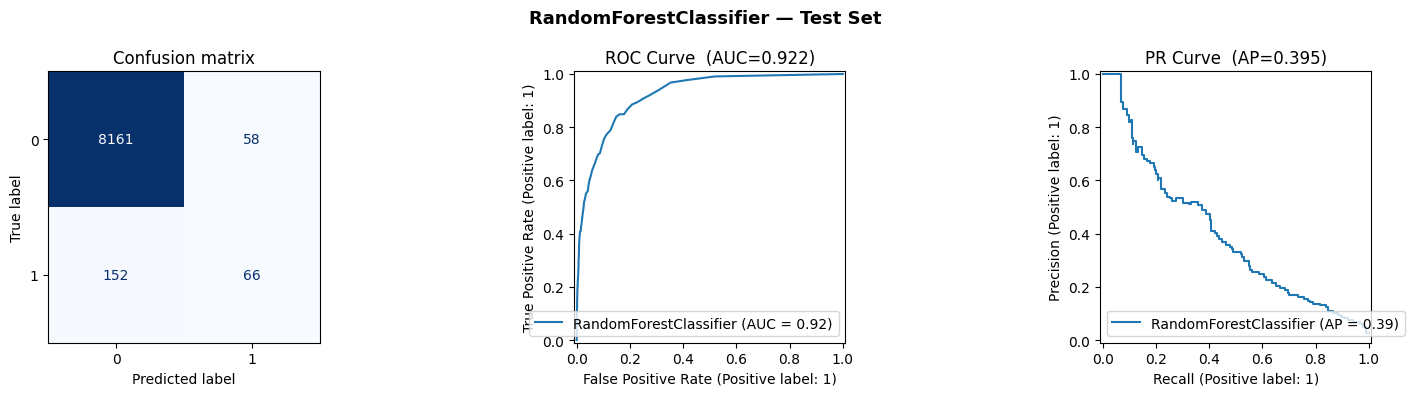

CPU times: user 15.8 s, sys: 171 ms, total: 16 s
Wall time: 45.6 s


In [8]:
%%time

rf_model = RandomForestClassifier(random_state = SEED)

print("Running RandomForest CV...")
with tqdm(total=CV_FOLDS, desc="RF CV folds") as pbar:
    rf_cv = run_cv(rf_model, X_train_sm, y_train_sm, "RandomForestClassifier")
    pbar.update(CV_FOLDS)

print("\nFitting RandomForest on full train & evaluating test...")
all_test_results["RandomForest"] = evaluate_test(
    rf_model, X_train_sm, y_train_sm, X_test, y_test, "RandomForestClassifier"
)

## 8. XGBClassifier

Running XGBoost CV …


XGB CV folds:   0%|          | 0/5 [00:00<?, ?it/s]


  5-Fold CV — XGBClassifier
                     Mean     Std  95% CI lower  95% CI upper
Metric                                                       
Balanced Accuracy  0.9816  0.0011        0.9802        0.9831
F1                 0.9816  0.0011        0.9802        0.9831
Roc Auc            0.9981  0.0001        0.9979        0.9983
Average Precision  0.9983  0.0001        0.9981        0.9984

Fitting XGBoost on full train & evaluating test …

  Test Evaluation — XGBClassifier
  Balanced Accuracy     : 0.6119
  F1 Score              : 0.2660
  Brier Score           : 0.0290
  AUC (ROC-AUC)         : 0.8936
  PR-AUC                : 0.2668


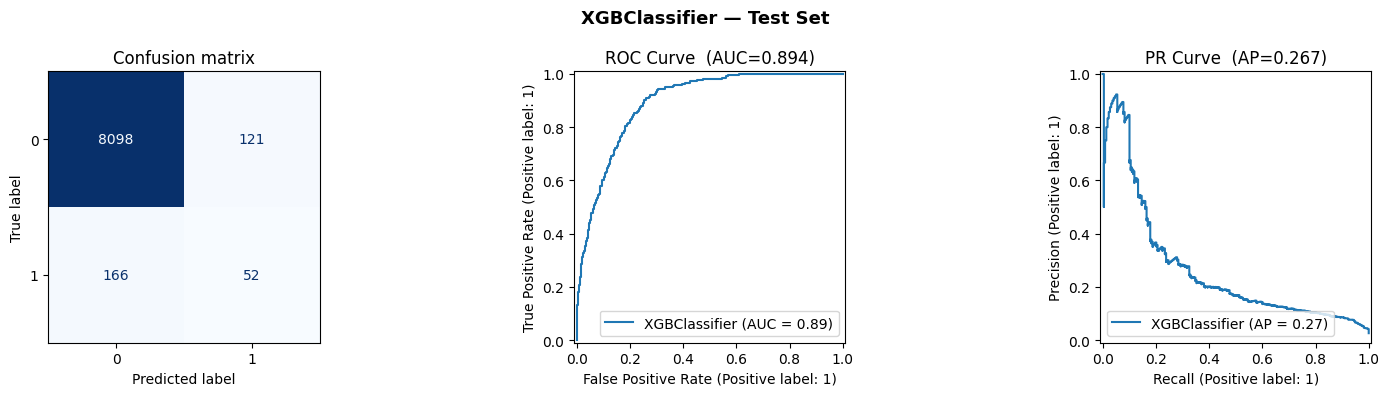

CPU times: user 2.64 s, sys: 122 ms, total: 2.76 s
Wall time: 3.08 s


In [9]:
%%time

xgb_model = XGBClassifier(random_state = SEED)

print("Running XGBoost CV...")
with tqdm(total=CV_FOLDS, desc="XGB CV folds") as pbar:
    xgb_cv = run_cv(xgb_model, X_train_sm, y_train_sm, "XGBClassifier")
    pbar.update(CV_FOLDS)

print("\nFitting XGBoost on full train & evaluating test...")
all_test_results["XGBoost"] = evaluate_test(
    xgb_model, X_train_sm, y_train_sm, X_test, y_test, "XGBClassifier"
)

## 9. ExplainableBoostingClassifier (EBM)

Running EBM CV (this model is sequential — may take several minutes) …


EBM CV folds:   0%|          | 0/5 [00:00<?, ?it/s]


  5-Fold CV — ExplainableBoostingClassifier
[LightGBM] [Info] Number of positive: 26296, number of negative: 26296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 52592, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 26296, number of negative: 26296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2339
[LightGBM] [Info] Number of data points in the train set: 52592, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [I

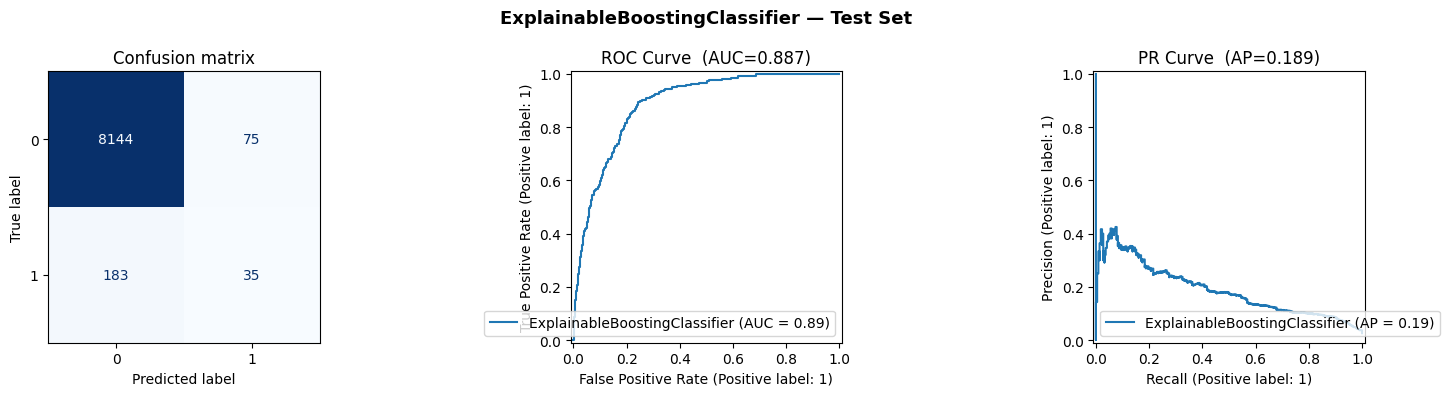

CPU times: user 38.5 s, sys: 17.6 s, total: 56.1 s
Wall time: 4h 42min 47s


In [10]:
%%time

ebm_model = ExplainableBoostingClassifier(random_state = SEED)

print("Running EBM CV...")
with tqdm(total=CV_FOLDS, desc="EBM CV folds") as pbar:
    ebm_cv = run_cv(ebm_model, X_train_sm, y_train_sm, "ExplainableBoostingClassifier")
    pbar.update(CV_FOLDS)

print("\nFitting EBM on full train & evaluating test...")
all_test_results["EBM"] = evaluate_test(
    ebm_model, X_train_sm, y_train_sm, X_test, y_test, "ExplainableBoostingClassifier"
)

---
## 10. Final comparison table

In [12]:
comparison_df = pd.DataFrame(all_test_results).T
comparison_df = comparison_df[
    ["Balanced Accuracy", "F1 Score", "Brier Score", "AUC (ROC-AUC)", "PR-AUC"]
]
comparison_df = comparison_df.round(4)

print("\n" + "—"*60)
print(" MODEL COMPARISON — TEST SET (imbalanced, untouched)")
print("—"*60)
print(comparison_df.to_string())

# Highlight best per metric
print("\nBest model per metric:")
for col in comparison_df.columns:
    if col == "Brier Score":
        best = comparison_df[col].idxmin()
    else:
        best = comparison_df[col].idxmax()
    print(f"  {col:<22}: {best}  ({comparison_df.loc[best, col]:.4f})")


 MODEL COMPARISON — TEST SET (imbalanced, untouched)
                  Balanced Accuracy  F1 Score  Brier Score  AUC (ROC-AUC)  PR-AUC
GradientBoosting             0.7303    0.1436       0.1082         0.8381  0.1047
LightGBM                     0.6200    0.2528       0.0360         0.8858  0.2020
RandomForest                 0.6478    0.3860       0.0233         0.9217  0.3947
XGBoost                      0.6119    0.2660       0.0290         0.8936  0.2668
EBM                          0.5757    0.2134       0.0257         0.8869  0.1889

Best model per metric:
  Balanced Accuracy     : GradientBoosting  (0.7303)
  F1 Score              : RandomForest  (0.3860)
  Brier Score           : RandomForest  (0.0233)
  AUC (ROC-AUC)         : RandomForest  (0.9217)
  PR-AUC                : RandomForest  (0.3947)


---
## 11. ROC & PR plots

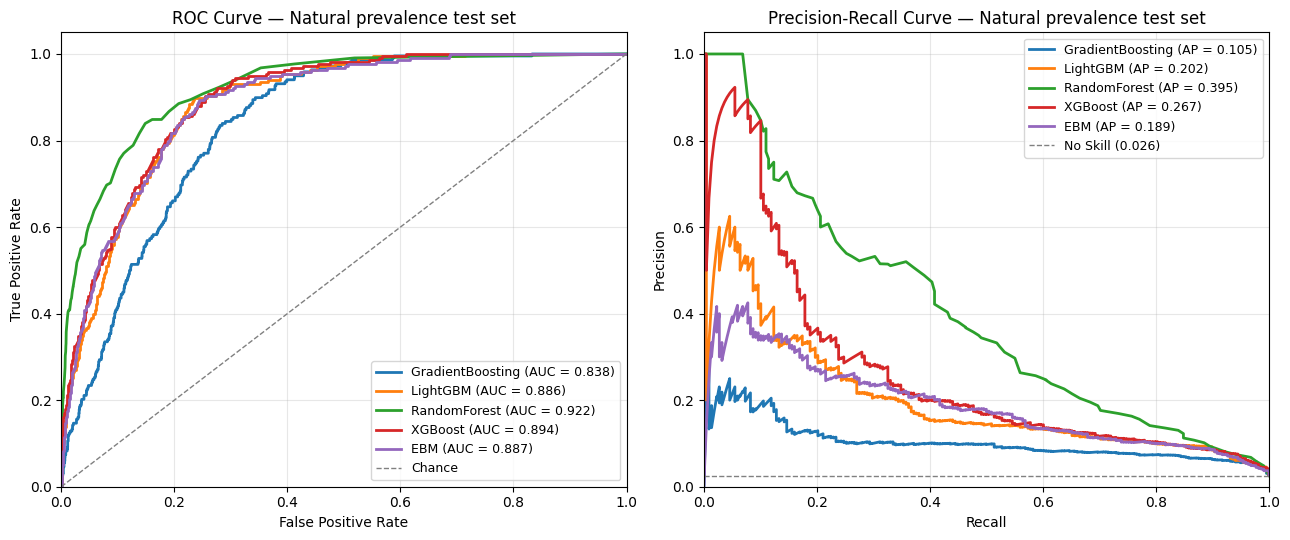

Saved: roc_pr_curves.png


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

trained_models = {
    "GradientBoosting" : gb_model,
    "LightGBM"         : lgbm_model,
    "RandomForest"     : rf_model,
    "XGBoost"          : xgb_model,
    "EBM"              : ebm_model
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC Curve
ax = axes[0]
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Natural prevalence test set")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
baseline = y_test.mean()

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax.plot(recall, precision, lw=2, label=f"{name} (AP = {pr_auc:.3f})")

ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"No Skill ({baseline:.3f})")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Natural prevalence test set")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: roc_pr_curves.png")

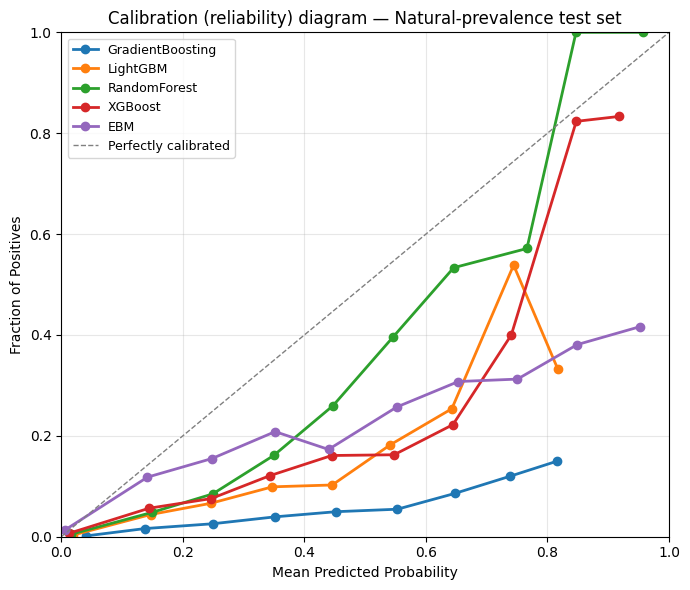

Saved: calibration_diagram.png


In [13]:
#  Calibration / Reliability diagram
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", lw=2, label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Perfectly calibrated")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration (Reliability) diagram — Natural-prevalence test set")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: calibration_diagram.png")

# Renal Complications — Balanced Dataset Pipeline
**Target:** `e112` | **Class balance:** 1092 vs 1092 (50/50) | **Seed:** 42

Pipeline:
1. 80/20 stratified split
2. No SMOTE (already balanced)
3. No cross-validation applied (dataset already balanced)
4. XGBoost · LightGBM · RandomForest · GradientBoosting · ExplainableBoostingMachine — **default hyperparameters**
5. Validation on held-out test set

## 0. Dependencies

In [2]:
!pip install interpret --quiet
!pip install lightgbm --quiet
!pip install xgboost --quiet

from importlib.metadata import version

print("interpret vers:", version('interpret'))
print("lightgbm:", version('lightgbm'))
print("xgboost:", version('xgboost'))
print("Install packages ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 11.8 MB/s eta 0:00:0000:010:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 53.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 58.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 62.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 13.5 MB/s eta 0:00:00
interpret vers: 0.7.8
lightgbm: 4.6.0
xgboost: 3.2.0
Install packages ✅


## 1. Imports & configuration

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print("Imports ✅ SEED =", SEED)

Imports ✅ SEED = 42


## 2. Load Data & 80/20 Stratified Split

In [ ]:
TARGET = "e112"
df_b = pd.read_csv("balanced-dataset.csv")

# Encode boolean column
df_b["cs_sex_M"] = df_b["cs_sex_M"].astype(int)

X_b = df_b.drop(columns=[TARGET])
y_b = df_b[TARGET].astype(int)

print(f"Dataset shape : {df_b.shape}")
print(f"Class distribution:\n{y_b.value_counts()}")

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b,
    test_size=0.20,
    stratify=y_b,
    random_state=SEED
)

print(f"\nTrain size : {X_train_b.shape[0]}  |  Test size : {X_test_b.shape[0]}")
print(f"Train positives : {y_train_b.sum()} ({100*y_train_b.mean():.2f}%)")
print(f"Test  positives : {y_test_b.sum()}  ({100*y_test_b.mean():.2f}%)")

Dataset shape : (2184, 13)
Class distribution:
e112
1    1092
0    1092
Name: count, dtype: int64

Train size : 1747  |  Test size : 437
Train positives : 874 (50.03%)
Test  positives : 218  (49.89%)


## 3. Train & evaluate all models with default hyperparameters

Training models:   0%|          | 0/5 [00:00<?, ?it/s]


  Test Evaluation — GradientBoosting
  Balanced Accuracy     : 0.7988
  F1 Score              : 0.8120
  Brier Score           : 0.1532
  AUC (ROC-AUC)         : 0.8430
  PR-AUC                : 0.7848


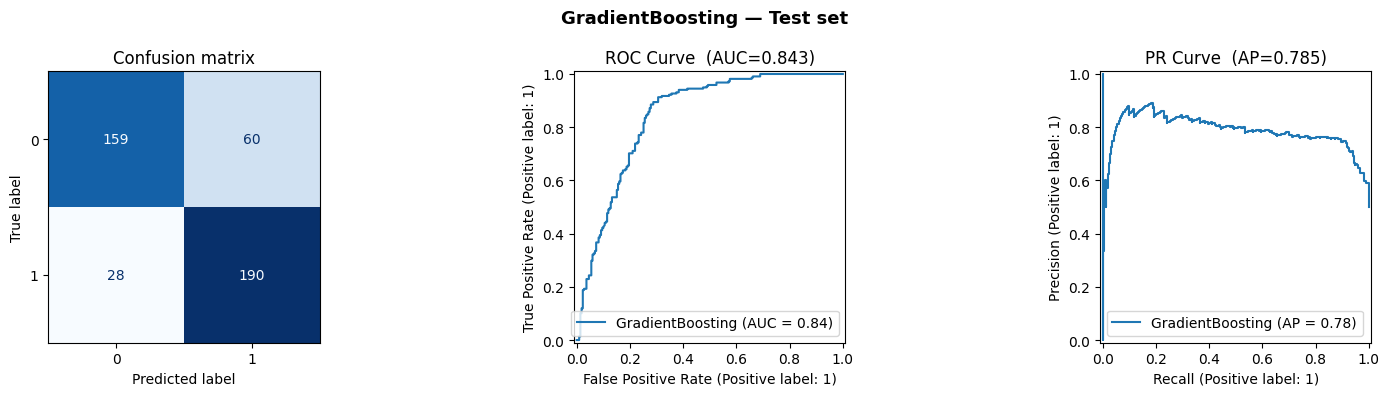

[LightGBM] [Info] Number of positive: 874, number of negative: 873
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 1747, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500286 -> initscore=0.001145
[LightGBM] [Info] Start training from score 0.001145

  Test Evaluation — LightGBM
  Balanced Accuracy     : 0.7781
  F1 Score              : 0.7877
  Brier Score           : 0.1443
  AUC (ROC-AUC)         : 0.8756
  PR-AUC                : 0.8413


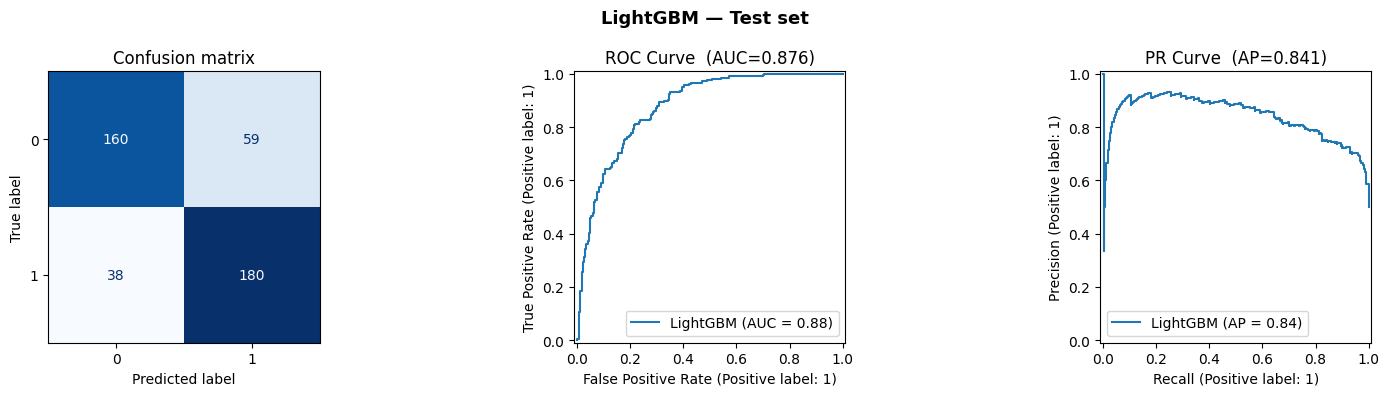


  Test Evaluation — RandomForest
  Balanced Accuracy     : 0.8148
  F1 Score              : 0.8266
  Brier Score           : 0.1337
  AUC (ROC-AUC)         : 0.8911
  PR-AUC                : 0.8612


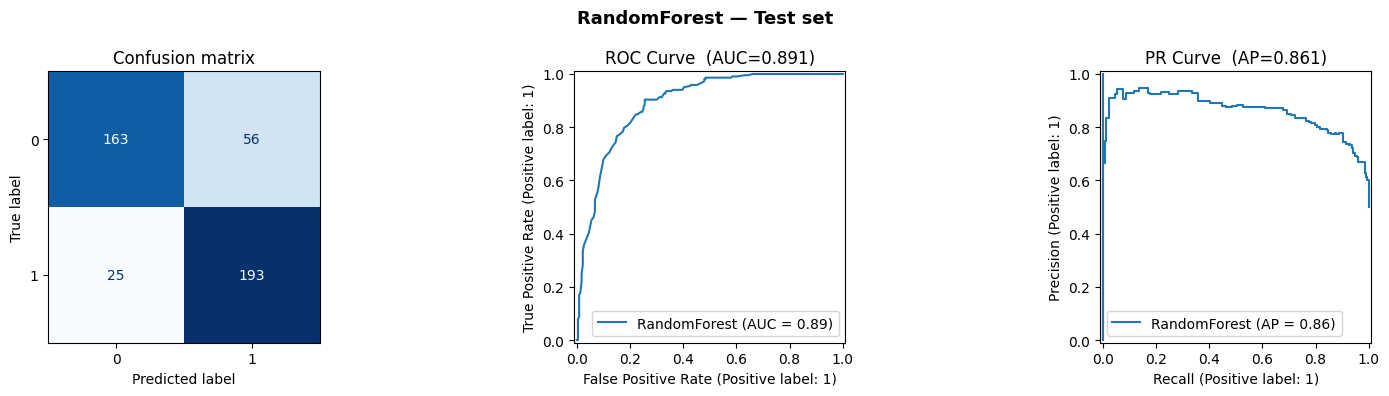


  Test Evaluation — XGBoost
  Balanced Accuracy     : 0.7804
  F1 Score              : 0.7895
  Brier Score           : 0.1533
  AUC (ROC-AUC)         : 0.8658
  PR-AUC                : 0.8221


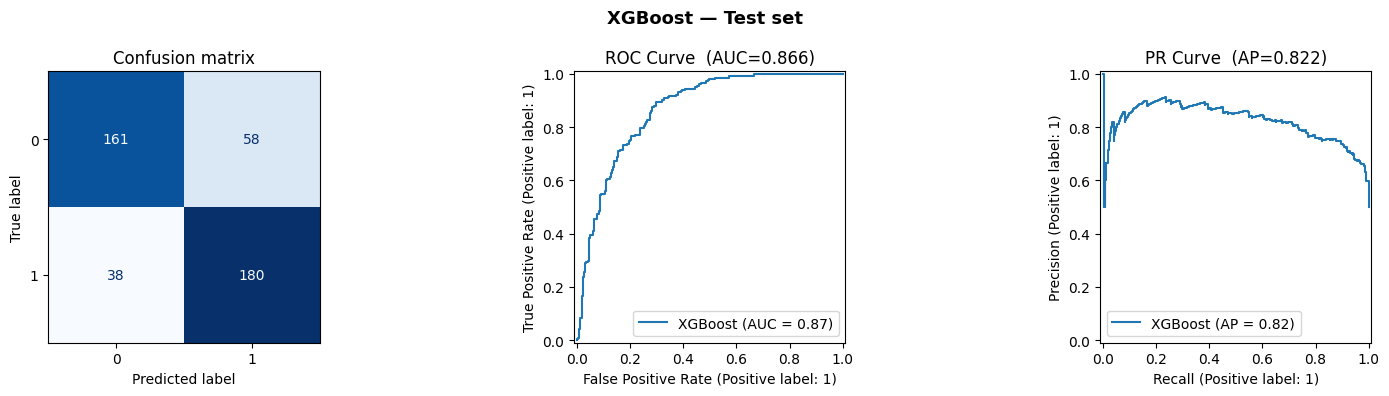


  Test Evaluation — EBM
  Balanced Accuracy     : 0.7919
  F1 Score              : 0.8051
  Brier Score           : 0.1519
  AUC (ROC-AUC)         : 0.8496
  PR-AUC                : 0.8006


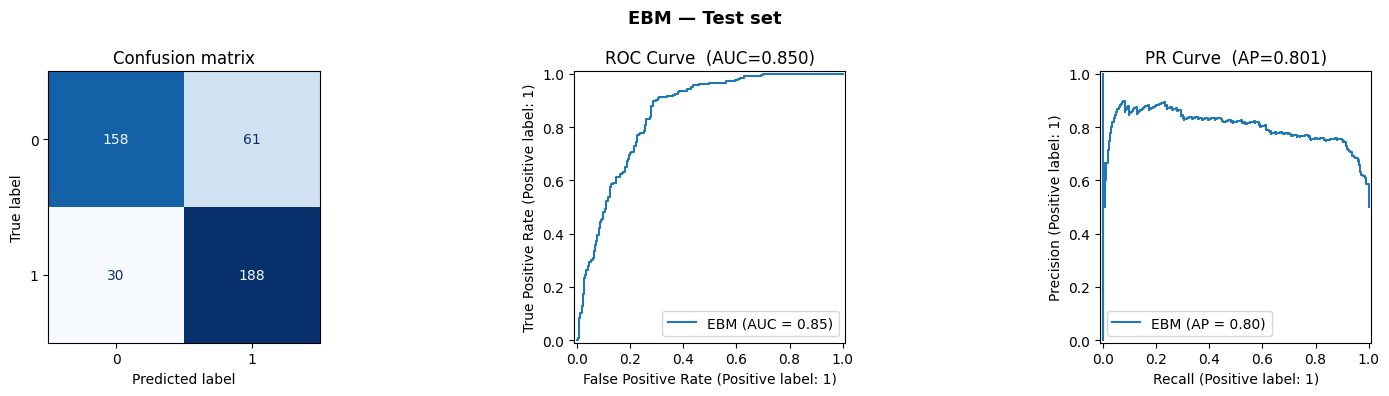

CPU times: user 2.99 s, sys: 133 ms, total: 3.12 s
Wall time: 30.9 s


In [11]:
%%time

#  Train all models with default hyperparameters and single evaluation pass
all_test_results_b = {}
trained_models_b   = {}

models_b = {
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "LightGBM": LGBMClassifier(random_state=SEED),
    "RandomForest": RandomForestClassifier(random_state=SEED),
    "XGBoost": XGBClassifier(random_state=SEED),
    "EBM": ExplainableBoostingClassifier(random_state=SEED),
}

for name, model in tqdm(models_b.items(), desc="Training models"):
    model.fit(X_train_b, y_train_b)
    y_pred_b  = model.predict(X_test_b)
    y_proba_b = model.predict_proba(X_test_b)[:, 1]

    metrics_b = {
        "Balanced Accuracy": balanced_accuracy_score(y_test_b, y_pred_b),
        "F1 Score"         : f1_score(y_test_b, y_pred_b, zero_division=0),
        "Brier Score"      : brier_score_loss(y_test_b, y_proba_b),
        "AUC (ROC-AUC)"    : roc_auc_score(y_test_b, y_proba_b),
        "PR-AUC"           : average_precision_score(y_test_b, y_proba_b),
    }

    print(f"\n{'='*60}")
    print(f"  Test Evaluation — {name}")
    print(f"{'='*60}")
    for k, v in metrics_b.items():
        print(f"  {k:<22}: {v:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{name} — Test set", fontsize=13, fontweight="bold")

    ConfusionMatrixDisplay.from_predictions(
        y_test_b,
        y_pred_b,
        ax=axes[0],
        colorbar=False,
        cmap="Blues"
    )
    axes[0].set_title("Confusion matrix")

    RocCurveDisplay.from_predictions(y_test_b, y_proba_b, ax=axes[1], name=name)
    axes[1].set_title(f"ROC Curve  (AUC={metrics_b['AUC (ROC-AUC)']:.3f})")

    PrecisionRecallDisplay.from_predictions(y_test_b, y_proba_b, ax=axes[2], name=name)
    axes[2].set_title(f"PR Curve  (AP={metrics_b['PR-AUC']:.3f})")

    plt.tight_layout()
    plt.show()

    all_test_results_b[name] = metrics_b
    trained_models_b[name]   = model

# Convenience references (used by later cells)
xgb_model_b, lgbm_model_b, rf_model_b, gb_model_b, ebm_model_b = (
    trained_models_b["GradientBoosting"],
    trained_models_b["LightGBM"],
    trained_models_b["RandomForest"],
    trained_models_b["XGBoost"],
    trained_models_b["EBM"],
)

## 4. Final comparison table

In [12]:
comparison_df_b = pd.DataFrame(all_test_results_b).T
comparison_df_b = comparison_df_b[
    ["Balanced Accuracy", "F1 Score", "Brier Score", "AUC (ROC-AUC)", "PR-AUC"]
]
comparison_df_b = comparison_df_b.round(4)

print("\n" + "="*70)
print(" MODEL COMPARISON — TEST SET")
print("—"*60)
print(comparison_df_b.to_string())

print("\nBest model per metric:")
for col in comparison_df_b.columns:
    if col == "Brier score":       # lower is better
        best = comparison_df_b[col].idxmin()
    else:
        best = comparison_df_b[col].idxmax()
    print(f"  {col:<22}: {best}  ({comparison_df_b.loc[best, col]:.4f})")


 MODEL COMPARISON — TEST SET
                  Balanced Accuracy  F1 Score  Brier Score  AUC (ROC-AUC)  PR-AUC
GradientBoosting             0.7988    0.8120       0.1532         0.8430  0.7848
LightGBM                     0.7781    0.7877       0.1443         0.8756  0.8413
RandomForest                 0.8148    0.8266       0.1337         0.8911  0.8612
XGBoost                      0.7804    0.7895       0.1533         0.8658  0.8221
EBM                          0.7919    0.8051       0.1519         0.8496  0.8006

Best model per metric:
  Balanced Accuracy     : RandomForest  (0.8148)
  F1 Score              : RandomForest  (0.8266)
  Brier Score           : RandomForest  (0.1337)
  AUC (ROC-AUC)         : RandomForest  (0.8911)
  PR-AUC                : RandomForest  (0.8612)


## 5. ROC & PR Curves

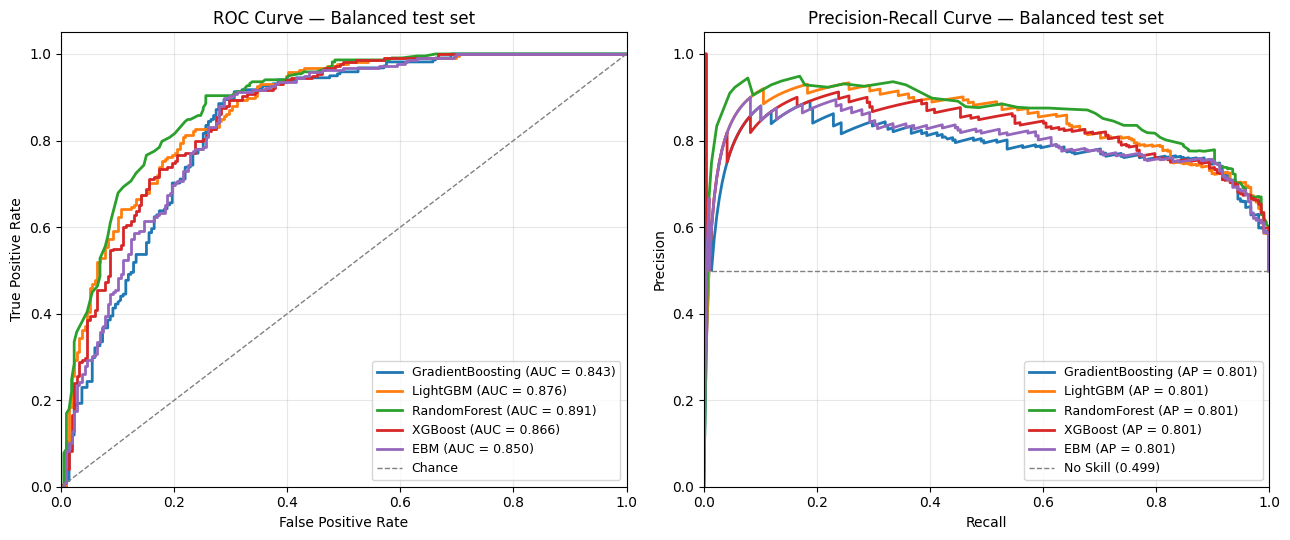

Saved: roc_pr_curves_balanced.png


In [35]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC Curve
ax = axes[0]
for name, model in trained_models_b.items():
    y_proba_b = model.predict_proba(X_test_b)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_b, y_proba_b)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Chance")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Balanced test set")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

# PR
ax = axes[1]
baseline = y_test_b.mean()
for name, model in trained_models_b.items():
    y_proba_b = model.predict_proba(X_test_b)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test_b, y_proba_b)
    pr_auc = average_precision_score(y_test_b, y_proba_b)
    ax.plot(recall, precision, lw=2, label=f"{name} (AP = {pr_auc:.3f})")

ax.axhline(baseline, linestyle="--", color="gray", lw=1,
           label=f"No Skill ({baseline:.3f})")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Balanced test set",)
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves_balanced.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: roc_pr_curves_balanced.png")

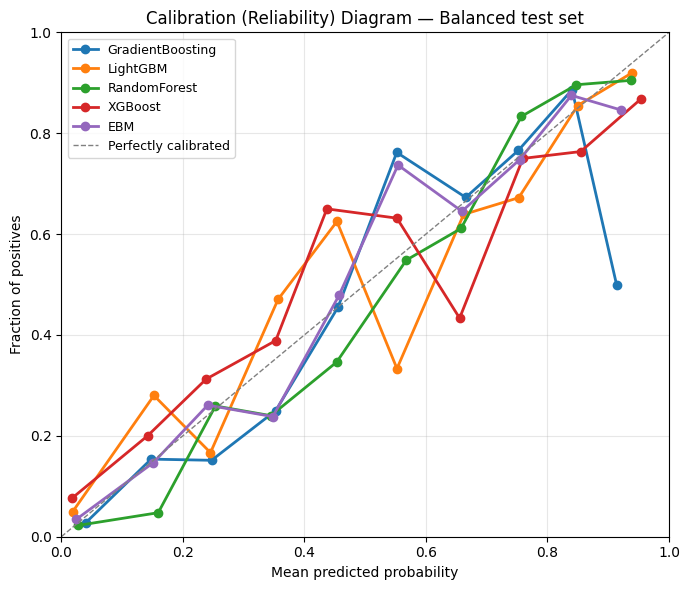

Saved: calibration_diagram_balanced.png


In [42]:
#  Calibration / Reliability diagram
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in trained_models_b.items():
    y_proba_b = model.predict_proba(X_test_b)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test_b, y_proba_b, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", lw=2, label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Perfectly calibrated")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration (Reliability) Diagram — Balanced test set")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_diagram_balanced.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: calibration_diagram_balanced.png")